In [5]:
import numpy as np
blood = np.array(['A', 'B', 'B', 'A', 'A', 'O', 'A', 'AB', 'O', 'O', 'A', 'B', 'AB', 'B', 'A'])

In [6]:
import pandas as pd
table1 = pd.crosstab(index = blood, colnames = ['Blood types'], columns = 'Frequency', margins = True)
table1.index = ['A', 'AB', 'B', 'O', 'Total']
print(table1)

Blood types  Frequency  All
A                    6    6
AB                   2    2
B                    4    4
O                    3    3
Total               15   15


In [7]:
for i in range(5):
    table1.iloc[i, 1] = table1.iloc[i, 1] / table1.iloc[4, 0]

table1.rename(columns = {'All' : 'Relative Freq'}, inplace = True)
print(table1)

Blood types  Frequency  Relative Freq
A                    6       0.400000
AB                   2       0.133333
B                    4       0.266667
O                    3       0.200000
Total               15       1.000000


In [8]:
import matplotlib.pyplot as plt

In [9]:
table2 = pd.crosstab(index = blood, colnames = ['Blood types'], columns = 'Frequency', margins = False)
table2.index = ['A', 'AB', 'B', 'O']

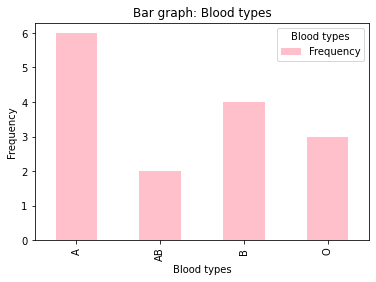

In [10]:
table2.plot(kind = 'bar', color = 'pink', legend = True)
plt.xlabel('Blood types')
plt.ylabel('Frequency')
plt.title('Bar graph: Blood types')
plt.show()

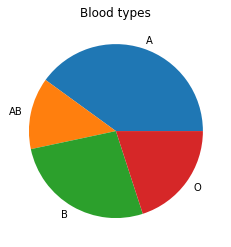

In [11]:
plt.pie(table2.iloc[:, 0], labels = table2.index)
plt.title("Blood types")
plt.show()

In [12]:
table3 = table2.sort_values(by = 'Frequency', ascending = False)
table3['cumulative rel freq'] = table3['Frequency'].cumsum() * 100 / table3['Frequency'].sum()
print(table3)

Blood types  Frequency  cumulative rel freq
A                    6            40.000000
B                    4            66.666667
O                    3            86.666667
AB                   2           100.000000


<Figure size 432x288 with 0 Axes>

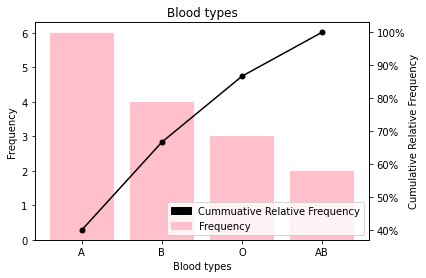

In [16]:
from matplotlib.ticker import PercentFormatter
import matplotlib.patches as mpatches

plt.figure()
fig, ax = plt.subplots()
ax.bar(table3.index, table3['Frequency'], color = 'pink')
ax2 = ax.twinx()
ax2.plot(table3.index, table3['cumulative rel freq'], color = 'black', marker = 'o', ms = 5)
ax2.yaxis.set_major_formatter(PercentFormatter())

p_legend1 = mpatches.Patch(color = 'black', label = 'Cummuative Relative Frequency')
p_legend2 = mpatches.Patch(color = 'pink', label = 'Frequency')
plt.legend(handles = [p_legend1, p_legend2], loc = 'lower right')

plt.title('Blood types')
ax.set_xlabel('Blood types')
ax.set_ylabel('Frequency')
plt.ylabel('Cumulative Relative Frequency')

plt.show()